# PRCP-1023 John Hopkins Covid19 project

Mounting the Drive to access raw data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing essential packages : required for time series

In [2]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data Preprocessing libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# Modeling libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utility libraries
import os
import warnings
warnings.filterwarnings('ignore')

# Date Handling tools
import datetime

Accessing raw data

In [3]:
base_path = '/content/drive/MyDrive/Colab Notebooks/Working projects/PRCP-1023 JohnHopkinsCovid19/prcp1023_dataset/'

confirmed_df = pd.read_csv(base_path + 'time_series_covid19_confirmed_global.csv')
deaths_df = pd.read_csv(base_path + 'time_series_covid19_deaths_global.csv')
recovered_df = pd.read_csv(base_path + 'time_series_covid19_recovered_global.csv')

In [4]:
confirmed_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [5]:
confirmed_df.tail()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
261,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,29906,30574,31362,32250,33006,33843,34401,35003,35686,36151
262,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,...,10,10,10,10,10,10,10,10,10,10
263,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2009,2011,2013,2016,2019,2022,2024,2026,2026,2028
264,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,13466,13539,13720,13819,13887,13928,14022,14070,14131,14175
265,NaN,Zimbabwe,-19.015438,29.154857,0,0,0,0,0,0,...,7508,7526,7531,7576,7598,7633,7647,7672,7683,7683


In [6]:
deaths_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,1420,1420,1425,1426,1436,1436,1437,1437,1441,1444
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,330,334,338,340,343,347,353,358,362,364
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,1605,1612,1620,1632,1645,1654,1659,1665,1672,1679
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,53,53,53,53,53,53,53,53,53,53
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,132,134,136,139,143,144,147,147,152,154


In [7]:
recovered_df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,31234,31638,32073,32098,32503,32505,32576,32576,32576,32576
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,6494,6569,6615,6668,6733,6788,6831,6888,6940,6995
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,33875,34037,34204,34385,34517,34675,34818,34923,35047,35180
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,943,943,945,945,1054,1054,1164,1164,1164,1199
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1289,1301,1324,1332,1401,1405,1443,1445,1445,1449


In [8]:
confirmed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


In [9]:
deaths_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


In [10]:
recovered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 490.3+ KB


**Reshaping the Data:** current format has one row per region and hundreds of columns for each date. That’s great for spreadsheets, but not for:
- Plotting trends over time
- Calculating daily changes, Hence reshaping the data (Wide → Long format)

In [11]:
# 🔄 Reshaping all three datasets from wide to long format
confirmed_long = confirmed_df.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='Date',
    value_name='Confirmed'
)

deaths_long = deaths_df.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='Date',
    value_name='Deaths'
)

recovered_long = recovered_df.melt(
    id_vars=['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name='Date',
    value_name='Recovered'
)

# 🗓️ Converting 'Date' column to datetime format
for df in [confirmed_long, deaths_long, recovered_long]:
    df['Date'] = pd.to_datetime(df['Date'])

**Region selection:** as per problem statement a specific region : India, is selected for model training and analysis

In [12]:
# Filtering and grouping data for India
india_confirmed = confirmed_long[confirmed_long['Country/Region'] == 'India']
india_confirmed = india_confirmed.groupby('Date')['Confirmed'].sum().reset_index()

india_deaths = deaths_long[deaths_long['Country/Region'] == 'India']
india_deaths = india_deaths.groupby('Date')['Deaths'].sum().reset_index()

india_recovered = recovered_long[recovered_long['Country/Region'] == 'India']
india_recovered = india_recovered.groupby('Date')['Recovered'].sum().reset_index()

Visualization of trends

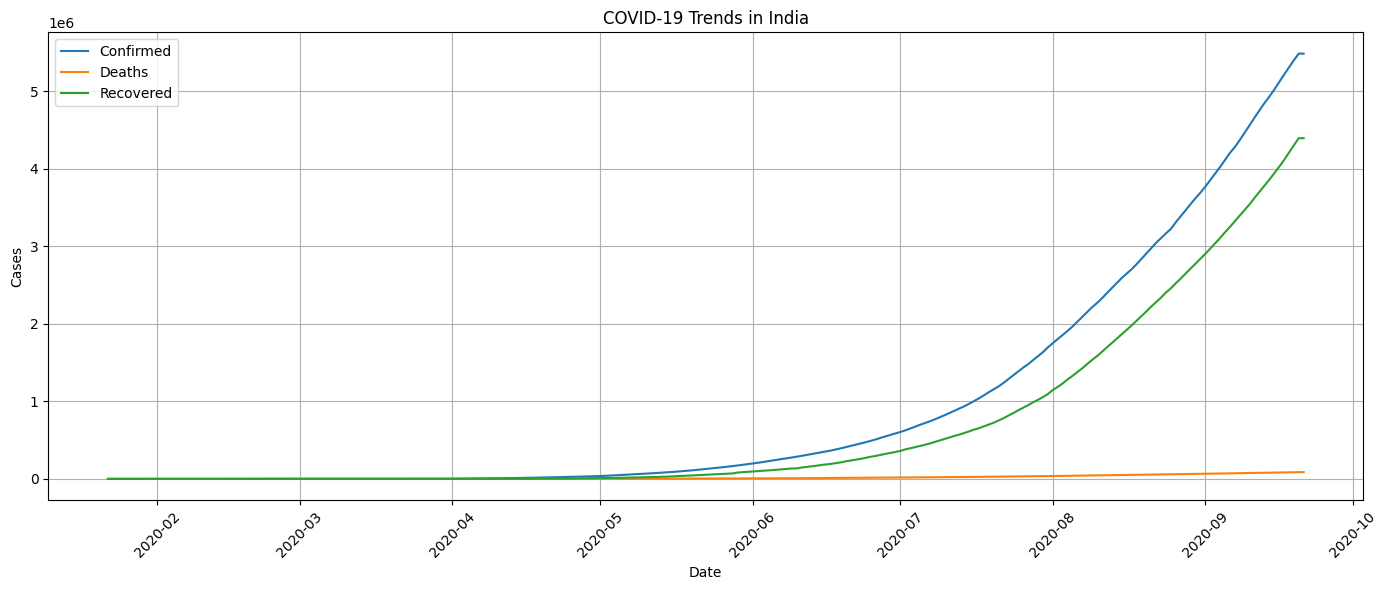

In [13]:
plt.figure(figsize=(14,6))
sns.lineplot(data=india_confirmed, x='Date', y='Confirmed', label='Confirmed')
sns.lineplot(data=india_deaths, x='Date', y='Deaths', label='Deaths')
sns.lineplot(data=india_recovered, x='Date', y='Recovered', label='Recovered')
plt.title('COVID-19 Trends in India')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Preparing data for modelling

In [14]:
india_confirmed['Daily_Confirmed'] = india_confirmed['Confirmed'].diff().fillna(0)
india_deaths['Daily_Deaths'] = india_deaths['Deaths'].diff().fillna(0)
india_recovered['Daily_Recovered'] = india_recovered['Recovered'].diff().fillna(0)

DataFrame : Merging data to create dataframe

In [15]:
india_data = india_confirmed[['Date', 'Confirmed', 'Daily_Confirmed']].merge(
    india_deaths[['Date', 'Deaths', 'Daily_Deaths']], on='Date'
).merge(
    india_recovered[['Date', 'Recovered', 'Daily_Recovered']], on='Date'
)

**Period selection** : dataset ends on 2020-09-01, hence:
- Training on data from 2020-03-01 to 2020-08-01
- Predicting for 2020-08-02 to 2020-09-01
This gives us a 5-month training window and a 1-month test window.

In [64]:
train_data = india_data[india_data['Date'] <= '2020-08-01']
test_data = india_data[india_data['Date'] > '2020-08-01'].set_index('Date')

Using lag features for basic start. Attempting to predict today's cases.

**Model** **Training**

**LinearRegression**

In [18]:
from sklearn.linear_model import LinearRegression

X_train = train_data[[f'Lag_{i}' for i in range(1, 8)]]
y_train = train_data['Daily_Confirmed']

X_test = test_data[[f'Lag_{i}' for i in range(1, 8)]]
y_test = test_data['Daily_Confirmed']

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

Visualizing and Evaluating LinearRegression

MSE: 265635869.20
R² Score: 0.15


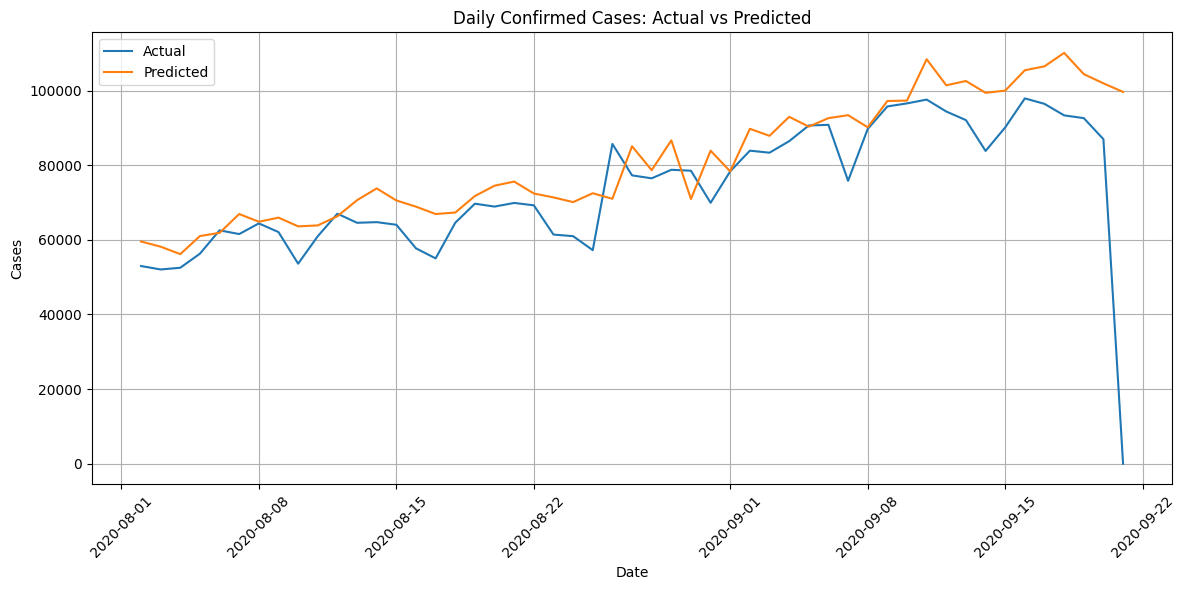

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f'MSE: {mse:.2f}')
print(f'R² Score: {r2:.2f}')

# Plotting actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(test_data['Date'], y_test, label='Actual')
plt.plot(test_data['Date'], predictions, label='Predicted')
plt.title('Daily Confirmed Cases: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Possible reasons for divergence toward mid-September :
📉 A sudden shift in real-world dynamics (policy changes, testing rates, etc.)
📊 Model limitations (LR assumes linearity, which may not hold during surges or drops)
🧮 Feature scope (lag features alone might not capture seasonality or external shocks)


## **Adding Rolling average feature which smooths out short-term fluctuations by averaging values over a fixed window of time.**

In [20]:
india_data['7_day_avg'] = india_data['Daily_Confirmed'].rolling(window=7).mean()
india_data.dropna(inplace=True)  # Dropping initial NaNs from rolling

In [21]:
# Updating training after rolling average

# Adding rolling average
india_data['7_day_avg'] = india_data['Daily_Confirmed'].rolling(window=7).mean()
india_data.dropna(inplace=True)  # Drop rows with NaNs from rolling

# Re-splitting after adding the new feature
train_data = india_data[india_data['Date'] <= '2020-08-01']
test_data = india_data[india_data['Date'] > '2020-08-01']

In [22]:
# Retraining the model

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [23]:
# Re-evaluating the performance

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Updated MSE: {mse:.2f}")
print(f"Updated R² Score: {r2:.2f}")

Updated MSE: 265635869.20
Updated R² Score: 0.15


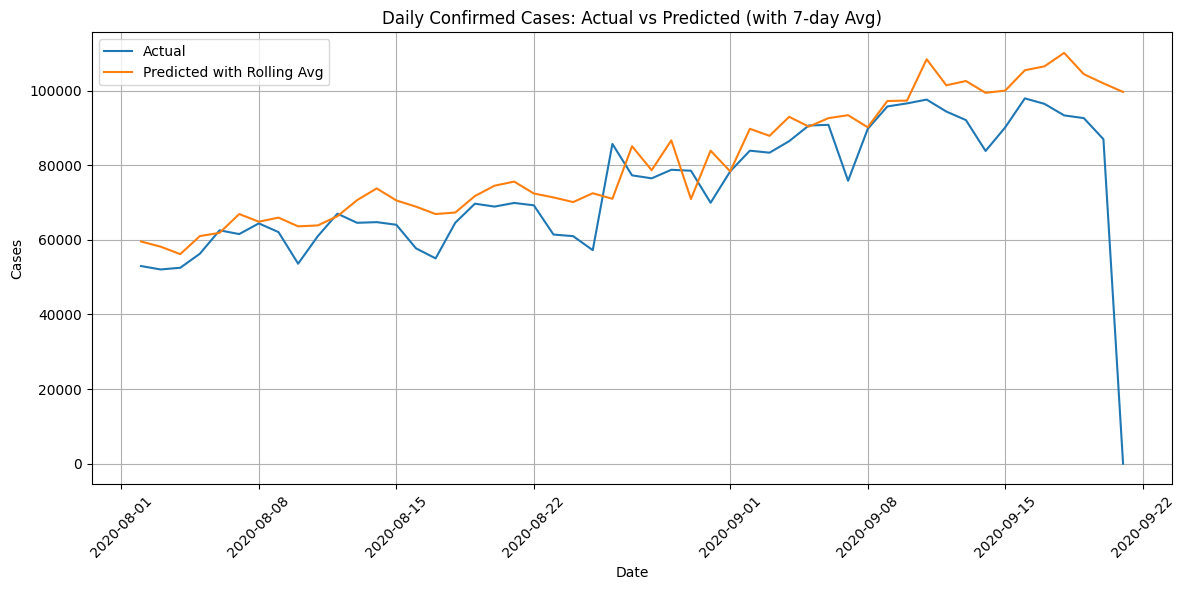

In [24]:
# Visualization of performance

plt.figure(figsize=(12,6))
plt.plot(test_data['Date'], y_test, label='Actual')
plt.plot(test_data['Date'], predictions, label='Predicted with Rolling Avg')
plt.title('Daily Confirmed Cases: Actual vs Predicted (with 7-day Avg)')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = y_test
y_pred = predictions

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred)

# MAPE
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Print results
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

MAE: 8845.43
RMSE: 265635869.20
MAPE: 9.69%
sMAPE: 12.87%


**RandomForestRegressor : Model for nonlinear data**

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [30]:
# Training the model

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [31]:
# Evaluating performance

from sklearn.metrics import mean_squared_error, r2_score

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MSE: {rf_mse:.2f}")
print(f"Random Forest R² Score: {rf_r2:.2f}")

Random Forest MSE: 586837319.77
Random Forest R² Score: -0.87


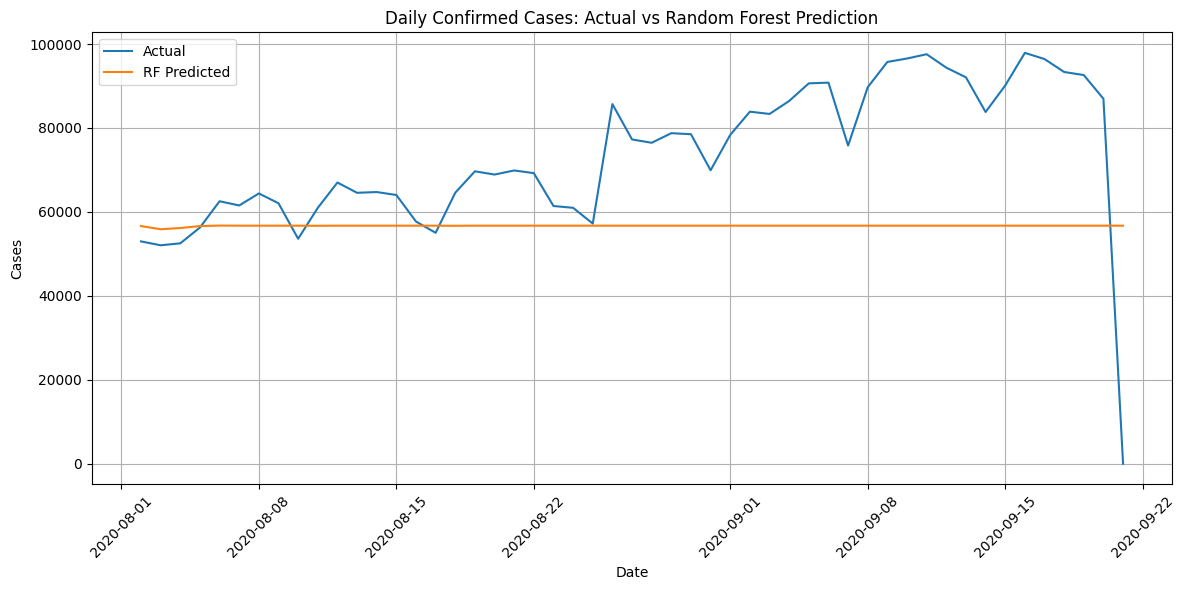

In [32]:
# Visualization of performance

plt.figure(figsize=(12,6))
plt.plot(test_data['Date'], y_test, label='Actual')
plt.plot(test_data['Date'], rf_predictions, label='RF Predicted')
plt.title('Daily Confirmed Cases: Actual vs Random Forest Prediction')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Adding more features and retraining.

# Rolling average
india_data['7_day_avg'] = india_data['Daily_Confirmed'].rolling(window=7).mean()

# Growth rate
india_data['Growth_Rate'] = india_data['Daily_Confirmed'] / india_data['Confirmed']
india_data['Growth_Rate'].replace([np.inf, -np.inf], np.nan, inplace=True)

# Daily deaths and recoveries
india_data['Daily_Deaths'] = india_data['Deaths'].diff().fillna(0)
india_data['Daily_Recovered'] = india_data['Recovered'].diff().fillna(0)

# Lag features for confirmed cases
for lag in range(1, 8):
    india_data[f'Lag_{lag}'] = india_data['Daily_Confirmed'].shift(lag)

# Lag features for deaths and recoveries
for lag in range(1, 4):
    india_data[f'Death_Lag_{lag}'] = india_data['Daily_Deaths'].shift(lag)
    india_data[f'Recover_Lag_{lag}'] = india_data['Daily_Recovered'].shift(lag)

# Drop rows with NaNs from rolling and lagging
india_data.dropna(inplace=True)

In [34]:
# Re-splitting Data

train_data = india_data[india_data['Date'] <= '2020-08-01']
test_data = india_data[india_data['Date'] > '2020-08-01']

In [35]:
# Updating feature columns

feature_cols = (
    [f'Lag_{i}' for i in range(1, 8)] +        # Lagged daily confirmed
    ['7_day_avg', 'Growth_Rate'] +             # Trend features
    [f'Death_Lag_{i}' for i in range(1, 4)] +  # Lagged deaths
    [f'Recover_Lag_{i}' for i in range(1, 4)]  # Lagged recoveries
)

In [36]:
# Tuning parameters

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

In [37]:
# Retraining

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

In [38]:
# Evaluating performance

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print(f"Tuned RF MSE: {mse:.2f}")
print(f"Tuned RF R² Score: {r2:.2f}")

Tuned RF MSE: 657297913.58
Tuned RF R² Score: -1.10


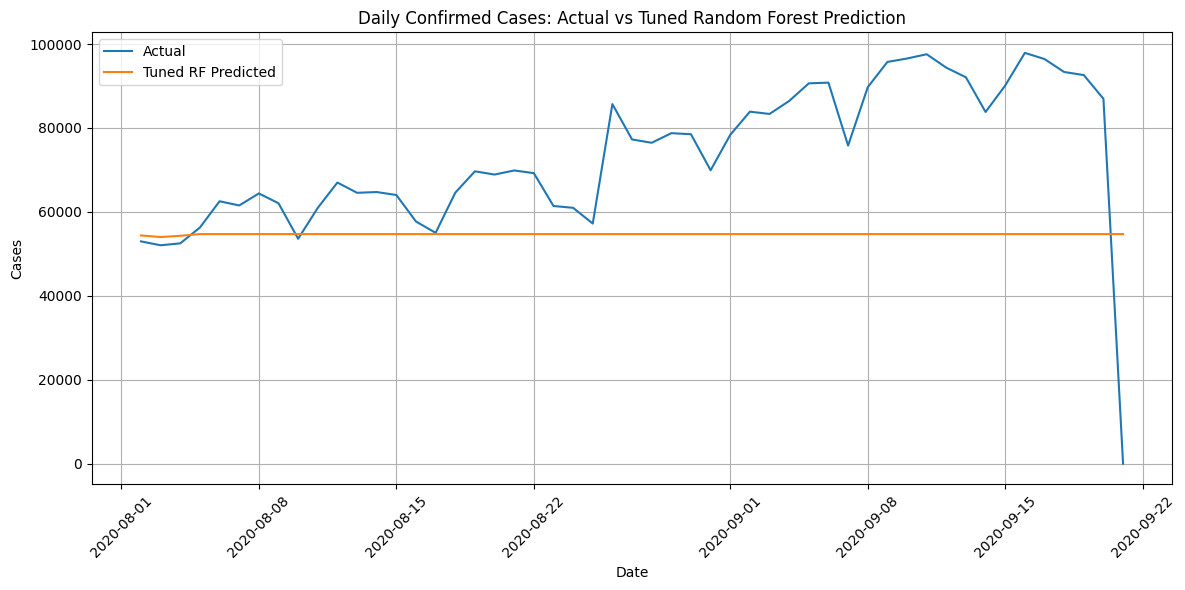

In [39]:
plt.figure(figsize=(12,6))
plt.plot(test_data['Date'], y_test, label='Actual')
plt.plot(test_data['Date'], rf_predictions, label='Tuned RF Predicted')
plt.title('Daily Confirmed Cases: Actual vs Tuned Random Forest Prediction')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = y_test
y_pred = rf_predictions

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred)

# MAPE (safe version to avoid division by zero)
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Print results
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

MAE: 20977.99
RMSE: 657297913.58
MAPE: 24.45%
sMAPE: 32.67%


**XGBoost** **model**

In [43]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

In [44]:
# Evaluating performance

from sklearn.metrics import mean_squared_error, r2_score

xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_r2 = r2_score(y_test, xgb_predictions)

print(f"XGBoost MSE: {xgb_mse:.2f}")
print(f"XGBoost R² Score: {xgb_r2:.2f}")

XGBoost MSE: 464027512.19
XGBoost R² Score: -0.48


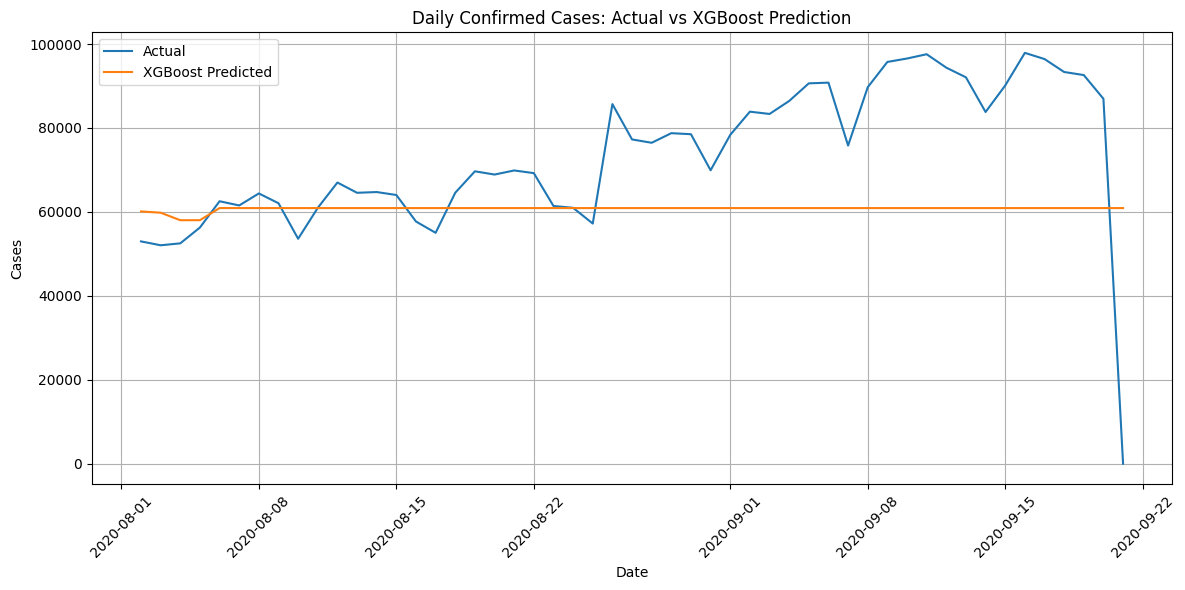

In [45]:
# Visualization

plt.figure(figsize=(12,6))
plt.plot(test_data['Date'], y_test, label='Actual')
plt.plot(test_data['Date'], xgb_predictions, label='XGBoost Predicted')
plt.title('Daily Confirmed Cases: Actual vs XGBoost Prediction')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = y_test
y_pred = xgb_predictions

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred) ** 0.5

# MAPE
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Print results
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

MAE: 16555.05
RMSE: 21541.30
MAPE: 18.71%
sMAPE: 25.04%


**ARIMA (AutoRegressive Integrated Moving Average)**

In [47]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(india_data['Daily_Confirmed'], order=(7,1,2))  # (p,d,q) tuned manually
model_fit = model.fit()
forecast = model_fit.predict(start=len(train_data), end=len(india_data)-1, typ='levels')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [48]:
# Fixing error, date time index

india_data['Date'] = pd.to_datetime(india_data['Date'])
india_data.set_index('Date', inplace=True)
india_data = india_data.asfreq('D')

In [49]:
# Retraining ARIMA

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(india_data['Daily_Confirmed'], order=(7,1,2))
model_fit = model.fit()

In [50]:
forecast = model_fit.predict(start=len(train_data), end=len(india_data)-1, typ='levels') # Forecasting without warnings

In [51]:
# Evaluating forecast accuracy

forecast = model_fit.predict(start=len(train_data), end=len(india_data)-1, typ='levels')

In [52]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, forecast)
r2 = r2_score(y_test, forecast)

print(f"ARIMA MSE: {mse:.2f}")
print(f"ARIMA R² Score: {r2:.2f}")

ARIMA MSE: 148774091.49
ARIMA R² Score: 0.52


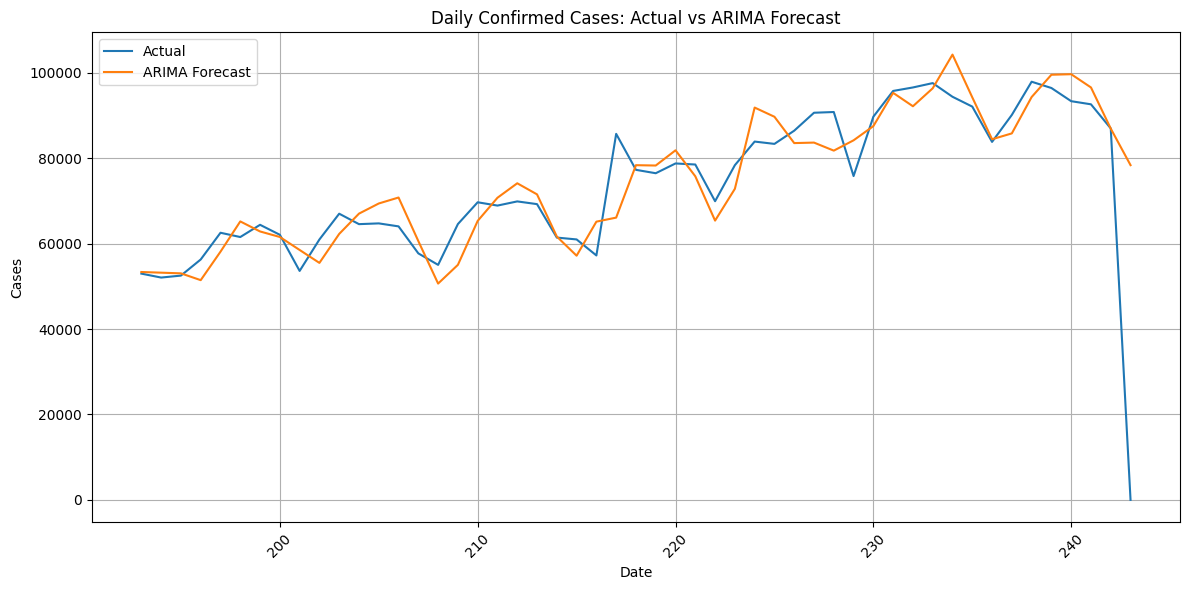

In [53]:
# Visualization

plt.figure(figsize=(12,6))
plt.plot(test_data.index, y_test, label='Actual')
plt.plot(test_data.index, forecast, label='ARIMA Forecast')
plt.title('Daily Confirmed Cases: Actual vs ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Forecast is series, while test_data is data frame, hence additional processing step

In [67]:
y_true = test_data['Daily_Confirmed']
y_pred = forecast

In [68]:
# Converting to numpy arrays and align lengths
y_true = np.array(y_true)
y_pred = np.array(y_pred)

min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

In [70]:
# Extracting the correct column from test_data
y_true = test_data['Daily_Confirmed'].values  # This gives a 1D numpy array
y_pred = forecast.values                      # Also a 1D numpy array

# Aligning lengths just in case
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5

non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

MAE: 5649.70
RMSE: 12197.30
MAPE: 5.68%
sMAPE: 9.54%


**SARIMA (Seasonal Autoregressive Integrated Moving Average)**

In [72]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    india_data['Daily_Confirmed'],
    order=(2, 1, 1),               # Non-seasonal AR lag changed to 2
    seasonal_order=(1, 1, 1, 7),   # Weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

In [73]:
# FOrecasting on test set

forecast = sarima_fit.predict(start=len(train_data), end=len(india_data)-1, typ='levels')

In [74]:
# Evaluating performance

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, forecast)
r2 = r2_score(y_test, forecast)

print(f"SARIMA MSE: {mse:.2f}")
print(f"SARIMA R² Score: {r2:.2f}")

SARIMA MSE: 141583882.41
SARIMA R² Score: 0.55


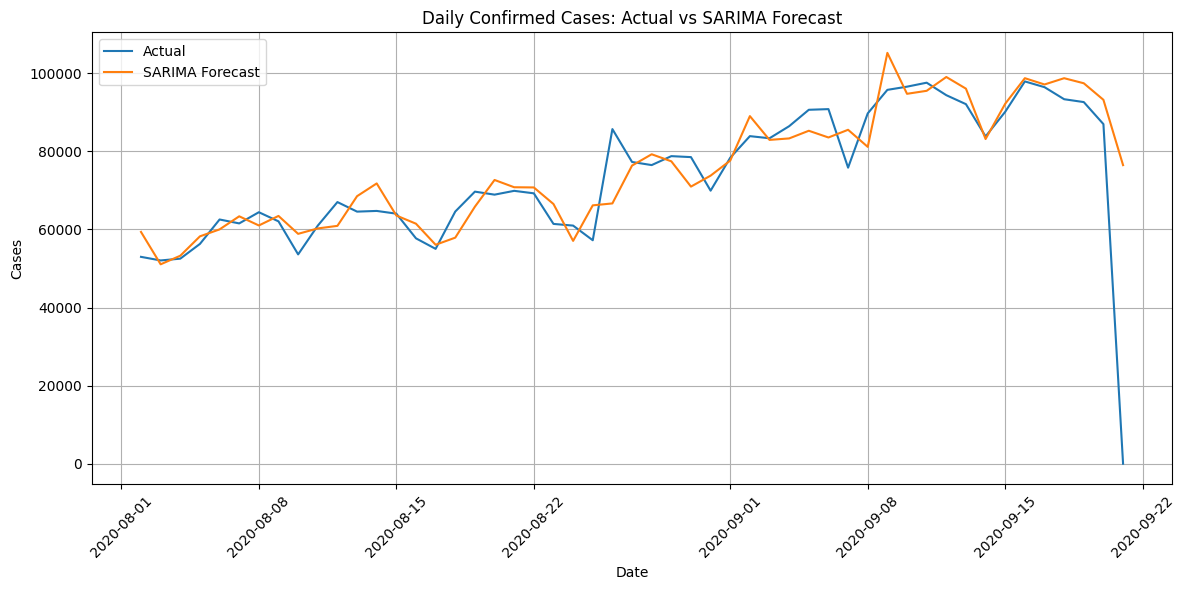

In [75]:
# Visualization

plt.figure(figsize=(12,6))
plt.plot(test_data.index, y_test, label='Actual')
plt.plot(test_data.index, forecast, label='SARIMA Forecast')
plt.title('Daily Confirmed Cases: Actual vs SARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Extracting actuals from test_data
y_true = test_data['Daily_Confirmed'].values
y_pred = forecast.values

# Aligning lengths
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred) ** 0.5

# MAPE
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Print results
print(f"SARIMA MAE: {mae:.2f}")
print(f"SARIMA RMSE: {rmse:.2f}")
print(f"SARIMA MAPE: {mape:.2f}%")
print(f"SARIMA sMAPE: {smape:.2f}%")

SARIMA MAE: 5433.04
SARIMA RMSE: 11898.90
SARIMA MAPE: 5.44%
SARIMA sMAPE: 9.25%


**Prophet (Model by Meta)**

In [77]:
from prophet import Prophet

In [91]:
# Step 1: Preparing data
prophet_df = india_data[['Daily_Confirmed']].copy()
prophet_df['ds'] = india_data.index
prophet_df.rename(columns={'Daily_Confirmed': 'y'}, inplace=True)

# Step 2: Splitting into train and test
train_size = len(train_data)
train_df = prophet_df.iloc[:train_size]
test_df = prophet_df.iloc[train_size:]

# Step 3: Training Prophet
model = Prophet()
model.fit(train_df)

# Step 4: Forecasting test period
future = model.make_future_dataframe(periods=len(test_df), freq='D')
forecast = model.predict(future)

# Step 5: Extracting predictions
y_pred = forecast['yhat'].iloc[train_size:].values
y_true = test_df['y'].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpri3q60hw/xekmvqsz.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpri3q60hw/aaay2asw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=73171', 'data', 'file=/tmp/tmpri3q60hw/xekmvqsz.json', 'init=/tmp/tmpri3q60hw/aaay2asw.json', 'output', 'file=/tmp/tmpri3q60hw/prophet_modelbbkdq6tz/prophet_model-20250916175713.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:57:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:57:13 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [92]:
# Evaluating performance

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Prophet MSE: {mse:.2f}")
print(f"Prophet R² Score: {r2:.2f}")

Prophet MSE: 346236249.30
Prophet R² Score: -0.11


Adjusting Prophet's configuration

In [93]:
model = Prophet(weekly_seasonality=True) # Enabling seasonality
model = Prophet(weekly_seasonality=True, changepoint_prior_scale=0.5) # Adding changepoint flexibility

In [94]:
# Reevaluating

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Prophet MSE: {mse:.2f}")
print(f"Prophet R² Score: {r2:.2f}")

Prophet MSE: 346236249.30
Prophet R² Score: -0.11


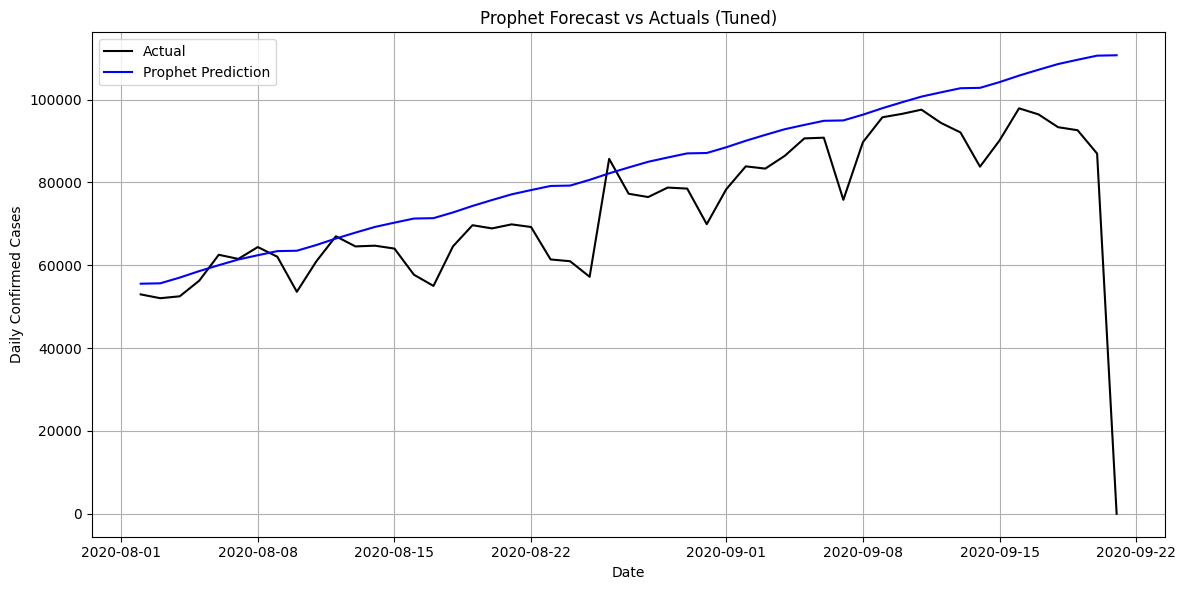

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_df['ds'], y_true, label='Actual', color='black')
plt.plot(test_df['ds'], y_pred, label='Prophet Prediction', color='blue')
plt.title('Prophet Forecast vs Actuals (Tuned)')
plt.xlabel('Date')
plt.ylabel('Daily Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [96]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Aligning lengths
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred) ** 0.5

# MAPE
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Print results
print(f"Prophet MAE: {mae:.2f}")
print(f"Prophet RMSE: {rmse:.2f}")
print(f"Prophet MAPE: {mape:.2f}%")
print(f"Prophet sMAPE: {smape:.2f}%")

Prophet MAE: 10444.35
Prophet RMSE: 18607.42
Prophet MAPE: 11.62%
Prophet sMAPE: 14.38%


**LSTM (Long short-term memory model)**

In [97]:
from sklearn.preprocessing import MinMaxScaler

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_5', 'Lag_6', 'Lag_7']
target = 'Daily_Confirmed'

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(india_data[features + [target]])

In [100]:
import numpy as np

X = scaled_data[:, :-1]  # lag features
y = scaled_data[:, -1]   # target

# Reshaping for LSTM: [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

In [101]:
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [102]:
# Building LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0403 - val_loss: 0.1868
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0116 - val_loss: 0.0289
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 0.0277
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 8.1466e-04 - val_loss: 0.0698
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.6666e-04 - val_loss: 0.0590
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.1388e-04 - val_loss: 0.0375
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.8419e-04 - val_loss: 0.0416
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.2307e-04 - val_loss: 0.0381
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.3265e-04 - val_loss: 0.0409
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.5881e-04 - val_loss: 0.0405
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 3.1865e-04 - val_loss: 0.0379
Epoch 12/50
11/11 ━━━━━━━━━━━━━

In [103]:
# Evaluation and inverting scale

y_pred = model.predict(X_test)

# Invert scaling
y_test_actual = scaler.inverse_transform(np.hstack((X_test.squeeze(), y_test.reshape(-1,1))))[:, -1]
y_pred_actual = scaler.inverse_transform(np.hstack((X_test.squeeze(), y_pred)))[:, -1]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


In [104]:
# Evaluation

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"LSTM MSE: {mse:.2f}")
print(f"LSTM R² Score: {r2:.2f}")

LSTM MSE: 239391012.19
LSTM R² Score: 0.24


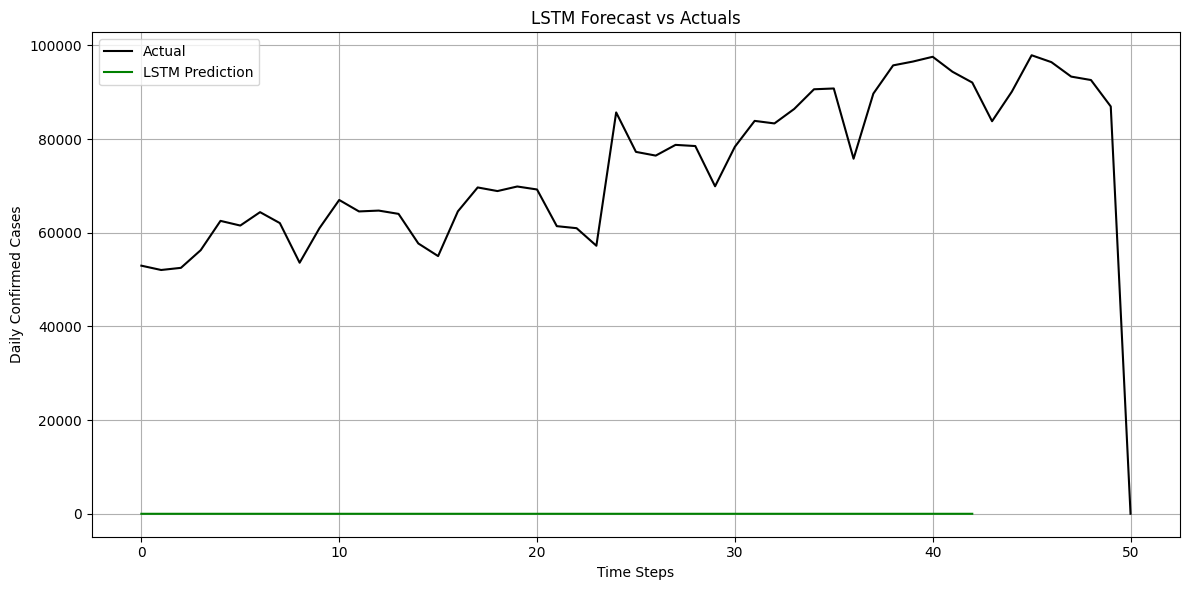

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual', color='black')
plt.plot(y_pred, label='LSTM Prediction', color='green')
plt.title('LSTM Forecast vs Actuals')
plt.xlabel('Time Steps')
plt.ylabel('Daily Confirmed Cases')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [108]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = y_test_actual
y_pred = y_pred_actual

# Aligning lengths
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE
rmse = mean_squared_error(y_true, y_pred) ** 0.5

# MAPE
non_zero_mask = y_true != 0
mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# sMAPE
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) # Add a small epsilon

# Print results
print(f"LSTM MAE: {mae:.2f}")
print(f"LSTM RMSE: {rmse:.2f}")
print(f"LSTM MAPE: {mape:.2f}%")
print(f"LSTM sMAPE: {smape:.2f}%")

LSTM MAE: 7295.30
LSTM RMSE: 15472.27
LSTM MAPE: 7.14%
LSTM sMAPE: 11.51%


# Model Comparision

In [109]:
import pandas as pd

# Store the metrics in a dictionary
model_metrics = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'ARIMA', 'SARIMA', 'LSTM'],
    'MAE': [8845.43, 20977.99, 16555.05, 5649.70, 5433.04, 7295.30],
    'RMSE': [np.sqrt(265635869.20), np.sqrt(657297913.58), np.sqrt(464027512.19), 12197.30, 11898.90, 15472.27],
    'MAPE (%)': [9.69, 24.45, 18.71, 5.68, 5.44, 7.14],
    'sMAPE (%)': [12.87, 32.67, 25.04, 9.54, 9.25, 11.51],
    'R² Score': [0.15, -1.10, -0.48, 0.52, 0.55, 0.24]
}

# Create a DataFrame
metrics_df = pd.DataFrame(model_metrics)

# Display the DataFrame
display(metrics_df)

,Model,MAE,RMSE,MAPE (%),sMAPE (%),R² Score
0,Linear Regression,8845.43,16298.339461,9.69,12.87,0.15
1,Random Forest,20977.99,25637.821935,24.45,32.67,-1.10
2,XGBoost,16555.05,21541.297830,18.71,25.04,-0.48
3,ARIMA,5649.70,12197.300000,5.68,9.54,0.52
4,SARIMA,5433.04,11898.900000,5.44,9.25,0.55
5,LSTM,7295.30,15472.270000,7.14,11.51,0.24


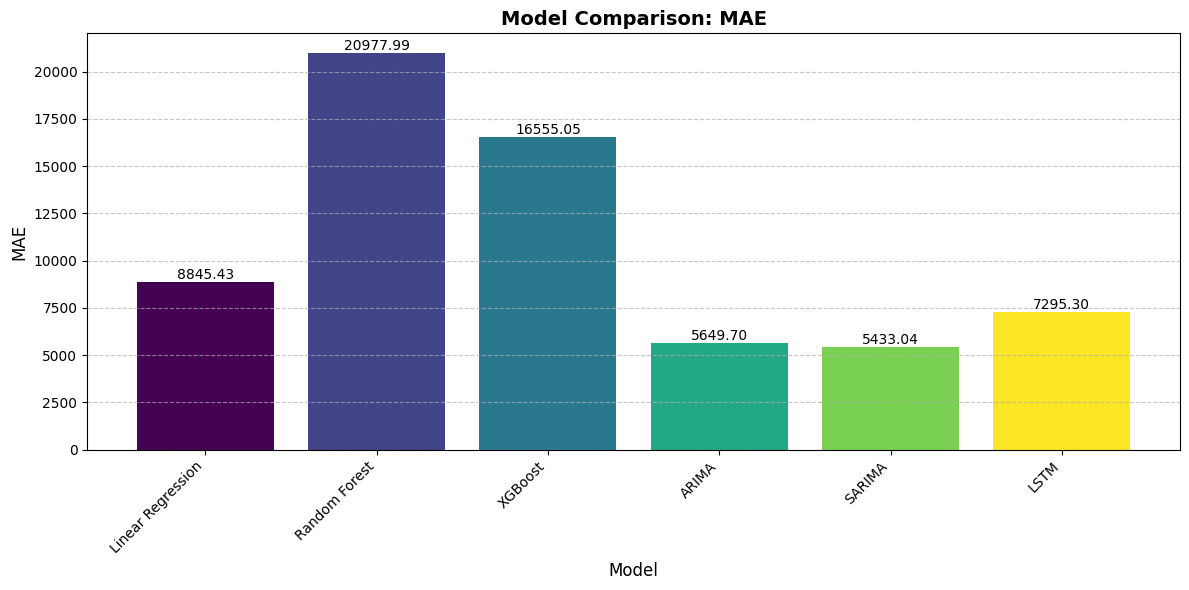

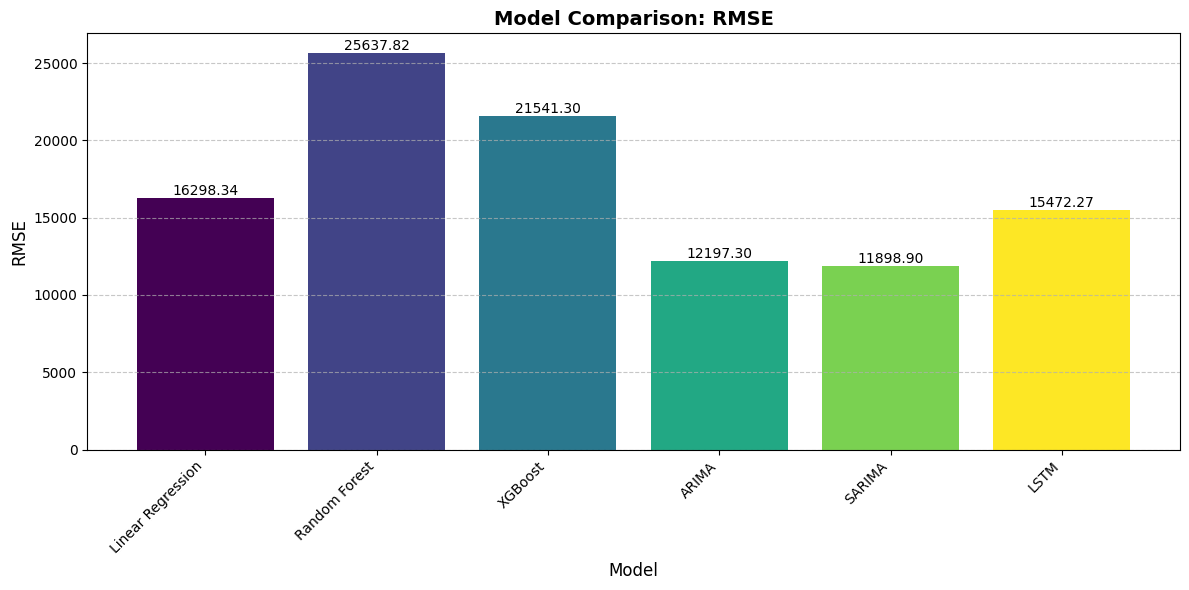

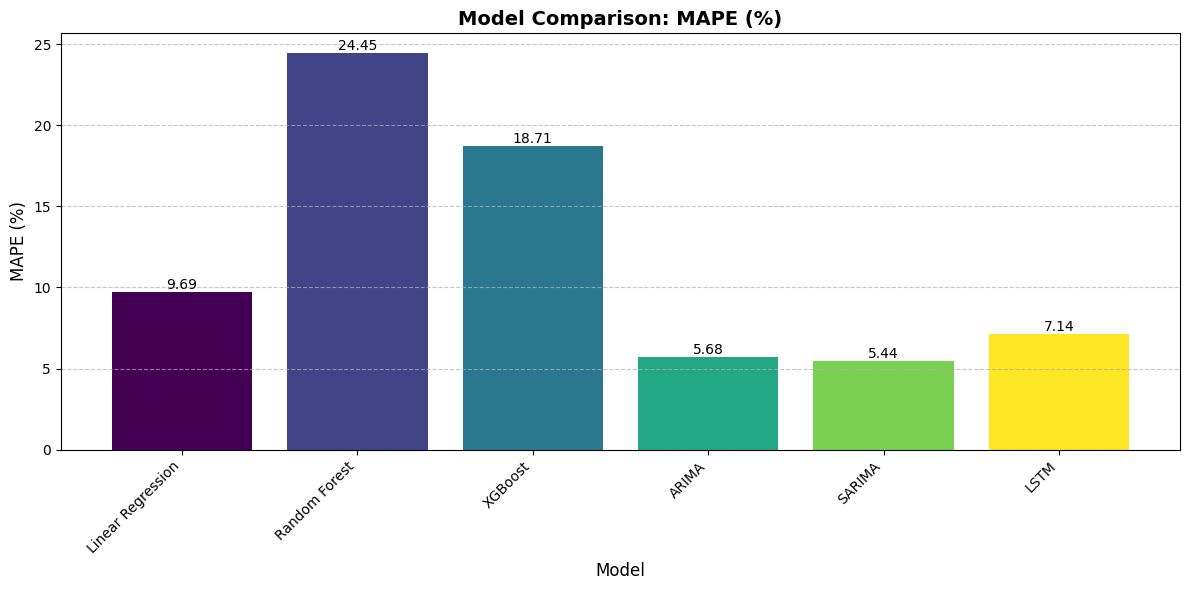

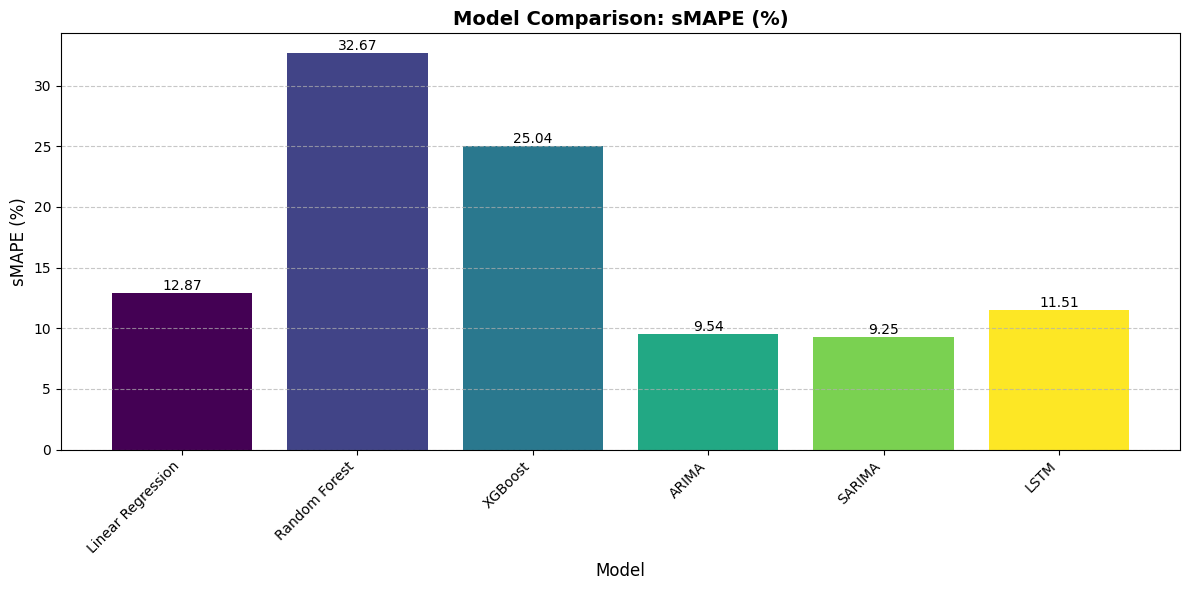

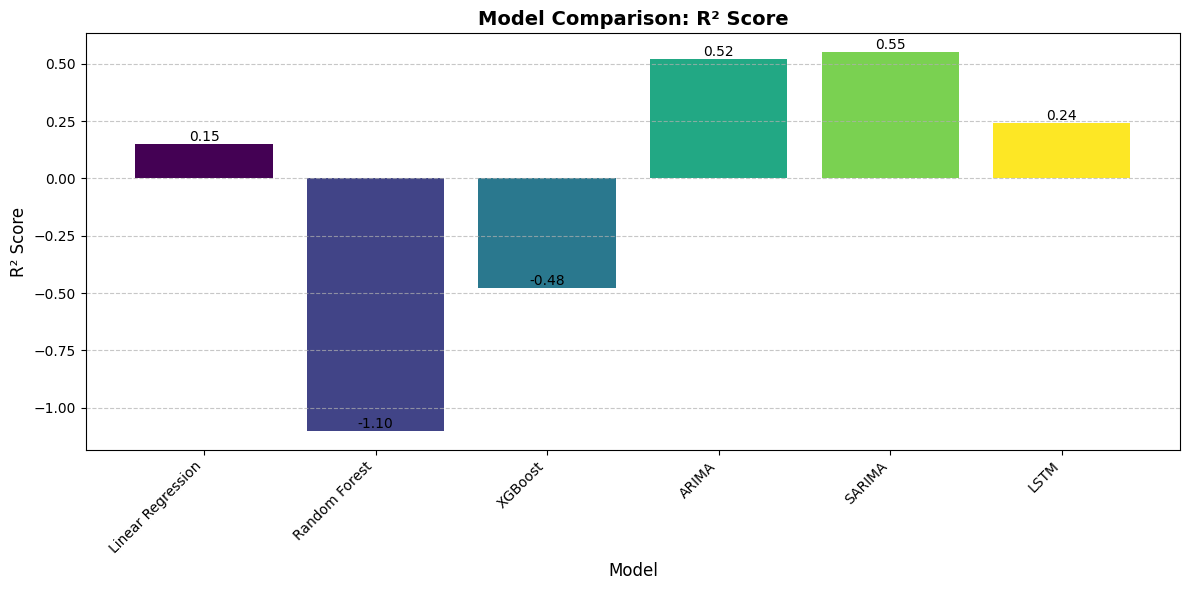

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming metrics_df is already created and contains the metrics

metrics = ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'R² Score']
titles = [
    'Model Comparison: MAE',
    'Model Comparison: RMSE',
    'Model Comparison: MAPE (%)',
    'Model Comparison: sMAPE (%)',
    'Model Comparison: R² Score'
]

for metric, title in zip(metrics, titles):
    plt.figure(figsize=(12, 6))
    bars = plt.bar(metrics_df['Model'], metrics_df[metric], color=plt.cm.viridis(np.linspace(0, 1, len(metrics_df))))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Model', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom', ha='center') # Adjust va for placement


    plt.tight_layout()
    plt.show()